# ESCan ffDTF Envelopes

Starter notebook for envelope-based ffDTF analysis in hyperscanning data.

In [1]:
import os
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('..'))

from src.export import load_xarray_from_netcdf, get_export_metadata

In [ ]:
# Paths and scanning settings
export_folder = Path("/Users/admin/Library/CloudStorage/GoogleDrive-j.zygierewicz@uw.edu.pl/.shortcut-targets-by-id/1N4ySQ5GO6UE8fY2jnRkRUjBFm4XHrBRv/SYNCC-IN/WP4          - Joint study/UniWAW Data collection/UNIWAW_EEG_exported")
cleaned_signals_folder = Path('../../DATA_film_cleaned/EEG')
TARGET_EVENTS = ['Peppa', 'Brave', 'Incredibles']
# Define analysis electrodes: 
analysis_channels = ['F3', 'Fz', 'F4', 'C3', 'Cz', 'C4', 'P3', 'Pz', 'P4']

# Optional manual exclusion after visual/quality inspection
MANUAL_EXCLUDE_DYADS = ['W_044', 'W_057']  # e.g. ['W_013', 'W_027']

SMOKE_TEST = True  # Set True for quick test run on 2 dyads, False for full run on all valid dyads.
DO_ICA_PREPROCESSING = True  # switch not to repeat ICA preprocessing if already done once, as it is time-consuming. 
                              # Set to True for first run, or change in the hyperparameters,
                              # then switch to False for subsequent runs after ICA components have been saved.

## EEG scan: keep only dyads complete for all TARGET_EVENTS and annotate child group

In [3]:

FILE_RE = re.compile(r'^(W_\d+)_EEG_(ch|cg)_(.+)$')

def discover_role_files(root: Path, target_events):
    files = sorted(p for p in root.rglob('*.nc') if '_EEG_' in p.name)
    pairs = {}
    for p in files:
        m = FILE_RE.match(p.stem)
        if m is None:
            continue
        dyad_id, role, event = m.group(1), m.group(2), m.group(3)
        if event not in target_events:
            continue
        key = (dyad_id, event)
        pairs.setdefault(key, {})[role] = p

    complete = []
    for (dyad_id, event), roles in sorted(pairs.items()):
        if 'ch' in roles and 'cg' in roles:
            complete.append((dyad_id, event, roles['ch'], roles['cg']))
    return complete

pairs_all = discover_role_files(export_folder, TARGET_EVENTS)
if not pairs_all:
    raise FileNotFoundError(f'No complete child/caregiver EEG pairs found in: {export_folder}')

events_required = set(TARGET_EVENTS)
events_by_dyad = {}
for dyad_id, event, _, _ in pairs_all:
    events_by_dyad.setdefault(dyad_id, set()).add(event)

valid_dyads = sorted([
    dyad_id for dyad_id, evs in events_by_dyad.items()
    if events_required.issubset(evs)
])
if MANUAL_EXCLUDE_DYADS:
    valid_dyads = [d for d in valid_dyads if d not in set(MANUAL_EXCLUDE_DYADS)]

# Collect one child-group label per valid dyad (from first TARGET_EVENTS file)
pairs_lookup = {(dyad_id, event): (path_ch, path_cg) for dyad_id, event, path_ch, path_cg in pairs_all}
rows = []
for dyad_id in valid_dyads:
    path_ch, _ = pairs_lookup[(dyad_id, TARGET_EVENTS[0])]
    da_meta = load_xarray_from_netcdf(str(path_ch))
    meta = get_export_metadata(da_meta)
    child_group = meta.get('child_info', {}).get('group', np.nan)
    rows.append({
        'dyadID': dyad_id,
        'child_group': child_group,
        'n_events_present': len(events_by_dyad.get(dyad_id, set())),
    })

valid_dyads_df = pd.DataFrame(rows).sort_values('dyadID').reset_index(drop=True)
valid_pairs = [p for p in pairs_all if p[0] in set(valid_dyads)]

print('EEG scanning summary')
print(f'  Found complete dyad-event pairs (ch+cg): {len(pairs_all)}')
print(f'  Valid dyads with all {len(TARGET_EVENTS)} target events: {len(valid_dyads)}')
print(f'  Valid dyad-event pairs to analyze: {len(valid_pairs)}')
if not valid_dyads_df.empty:
    print('  Child-group counts:')
    print(valid_dyads_df['child_group'].value_counts(dropna=False))

display(valid_dyads_df.head(50))

EEG scanning summary
  Found complete dyad-event pairs (ch+cg): 173
  Valid dyads with all 3 target events: 53
  Valid dyad-event pairs to analyze: 159
  Child-group counts:
child_group
TD                26
ASD               16
P                  7
ASD+P              3
P, możliwe ASD     1
Name: count, dtype: int64


,dyadID,child_group,n_events_present
0,W_000,TD,3
1,W_001,TD,3
2,W_002,TD,3
3,W_003,TD,3
4,W_004,TD,3
5,W_005,TD,3
6,W_009,TD,3
7,W_010,TD,3
8,W_013,TD,3
9,W_014,TD,3


## ICA preprocessing on valid dyads (complete TARGET_EVENTS only)

In [4]:

if DO_ICA_PREPROCESSING:
    from src.ica_preprocessing import ICAPreprocessor



    if 'valid_dyads' not in globals() or len(valid_dyads) == 0:
        raise RuntimeError('valid_dyads is empty. Run the EEG scan cell first.')

    icap = ICAPreprocessor(
        export_folder=export_folder,
        target_events=TARGET_EVENTS,
        valid_dyads=valid_dyads,
    )

    # Set smoke_test=False for full run on all valid dyads.
    icap.find_eeg_files(smoke_test=SMOKE_TEST)

    icap.preprocess_and_save(
        cleaned_signals_folder=cleaned_signals_folder,
        ica_n_components=12,
        ica_max_iter=2000,
        eog_channels=['Fp1', 'Fp2'],
        eog_threshold=3.0,
        clean_muscle=True,
        muscle_l_freq_hz=8.0,
        muscle_threshold=0.4,
        muscle_max_fraction=0.4,
        protect_transients=True,
        transient_zscore_threshold=8.0,
        transient_min_channels=6,
        transient_padding_s=0.15,
        transient_max_fraction=0.15,
        transient_interpolate_output=True,
        save_plots=True,
    )

Mode: SMOKE TEST (first 2 dyads)
Dyads selected: 2 / 53
Files selected: 12 / 318
Complete dyads with all target events: 53
Applied valid_dyads allowlist: 53 dyads
Dyads:
  - W_000
  - W_001


## W_000_EEG_ch_Peppa

Processing & Saving: W_000_EEG_ch_Peppa.nc
  EOG ICs: [np.int64(0)]
  Muscle ICs: []
  Muscle detection status: ok (0.00 flagged)
  Final excluded ICs: [np.int64(0)]
Applying ICA to Raw instance
    Transforming to ICA space (12 components)
    Zeroing out 1 ICA component
    Projecting back using 21 PCA components
-> Saved NetCDF to: ../../DATA_film_cleaned/EEG/W_000/W_000_EEG_ch_Peppa_cleaned.nc
Saved plot preview to: ../../DATA_film_cleaned/EEG/W_000/W_000_EEG_ch_Peppa_cleaned_ica_plot.png


## W_000_EEG_cg_Peppa

Processing & Saving: W_000_EEG_cg_Peppa.nc
  EOG ICs: [np.int64(0)]
  Muscle ICs: [4, 5, 7]
  Muscle detection status: ok (0.25 flagged)
  Final excluded ICs: [np.int64(0), 4, 5, 7]
Applying ICA to Raw instance
    Transforming to ICA space (12 components)
    Zeroing out 4 ICA components
    Projecting back using 21 PCA components
-> Saved NetCDF to: ../../DATA_film_cleaned/EEG/W_000/W_000_EEG_cg_Peppa_cleaned.nc
Saved plot preview to: ../../DATA_film_cleaned/EEG/W_000/W_000_EEG_cg_Peppa_cleaned_ica_plot.png


...

Processing & Saving: W_001_EEG_ch_Incredibles.nc
  EOG ICs: []
  Muscle ICs: []
  Muscle detection status: ok (0.00 flagged)
  Final excluded ICs: []
Applying ICA to Raw instance
    Transforming to ICA space (12 components)
    Zeroing out 0 ICA components
    Projecting back using 21 PCA components
-> Saved NetCDF to: ../../DATA_film_cleaned/EEG/W_001/W_001_EEG_ch_Incredibles_cleaned.nc
Saved plot preview to: ../../DATA_film_cleaned/EEG/W_001/W_001_EEG_ch_Incredibles_cleaned_ica_plot.png


## W_001_EEG_cg_Incredibles

Processing & Saving: W_001_EEG_cg_Incredibles.nc
  EOG ICs: [np.int64(1)]
  Muscle ICs: [3, 8, 10]
  Muscle detection status: ok (0.25 flagged)
  Final excluded ICs: [np.int64(1), 3, 8, 10]
Applying ICA to Raw instance
    Transforming to ICA space (12 components)
    Zeroing out 4 ICA components
    Projecting back using 21 PCA components
-> Saved NetCDF to: ../../DATA_film_cleaned/EEG/W_001/W_001_EEG_cg_Incredibles_cleaned.nc


/Users/admin/Documents/Hoza/PROJEKTY/SYNCC_IN_LOCAL_HOME/hyperscanning-signal-analysis/src/ica_preprocessing.py:399: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw_for_ica.set_annotations(raw_for_ica.annotations + ann)


Saved plot preview to: ../../DATA_film_cleaned/EEG/W_001/W_001_EEG_cg_Incredibles_cleaned_ica_plot.png


## PSD overlay (Welch, nperseg=2*fs) for cleaned EEG

Analysis electrodes:
['F3', 'Fz', 'F4', 'C3', 'Cz', 'C4', 'P3', 'Pz', 'P4']


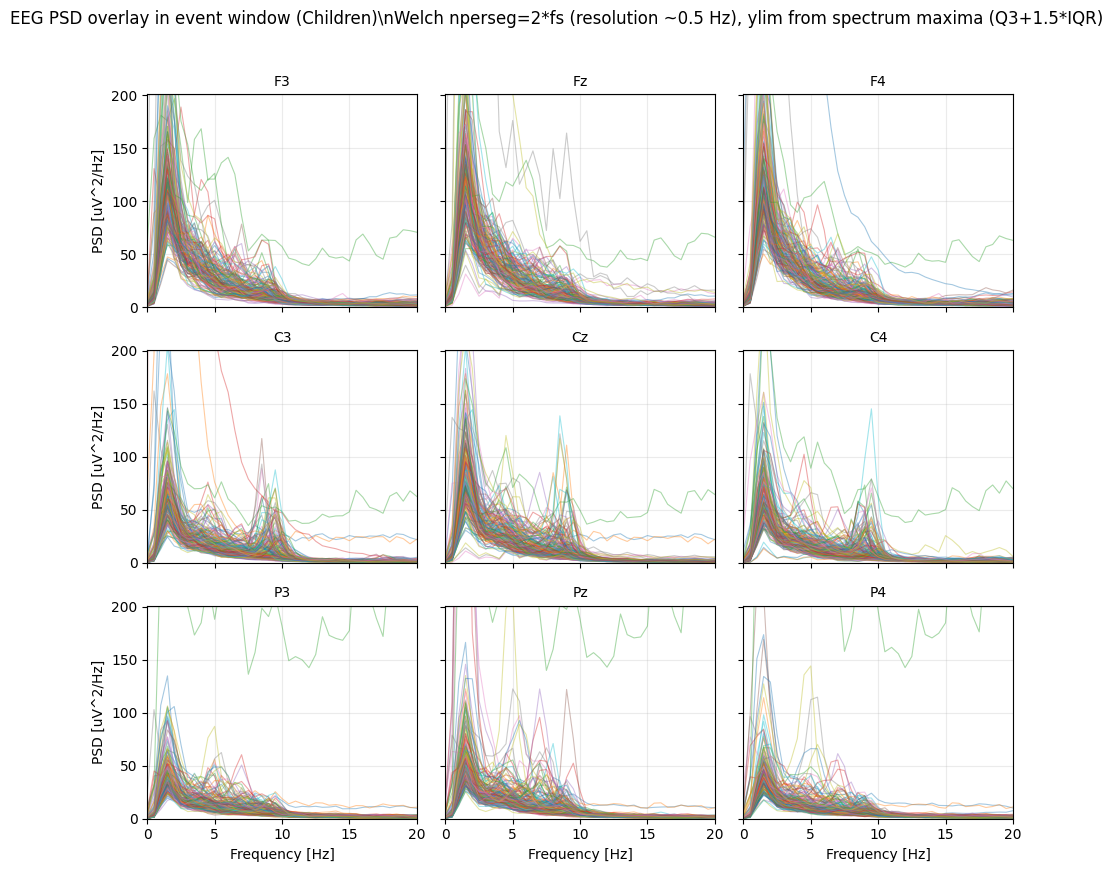

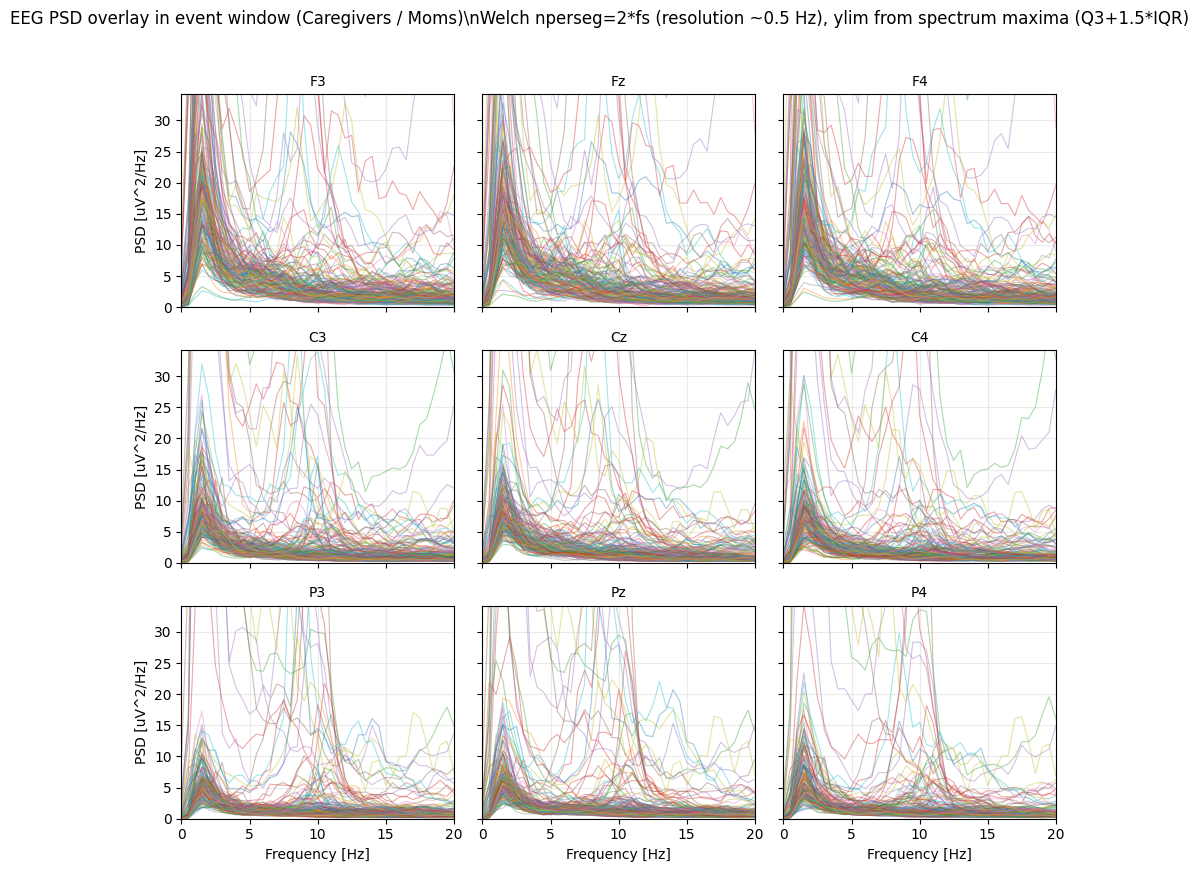

In [5]:
# PSD overlay (Welch, nperseg=2*fs) for cleaned EEG in event window, split by role
from collections import defaultdict
import re
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.signal import welch

CLEAN_RE = re.compile(r'^(W_\d+)_EEG_(ch|cg)_(.+)_cleaned$')

def infer_fs(time_s, attrs):
    fs_attr = attrs.get('sampling_freq', np.nan)
    if np.isfinite(fs_attr) and fs_attr > 0:
        return float(fs_attr)
    if len(time_s) < 2:
        return np.nan
    dt = np.median(np.diff(time_s))
    return float(1.0 / dt) if dt > 0 else np.nan

def get_event_mask(time_s, attrs):
    event_start = float(attrs.get('event_start', 0.0))
    event_duration = float(attrs.get('event_duration', attrs.get('event_duration_s', np.nan)))

    if np.isfinite(event_duration) and event_duration > 0:
        return (time_s >= event_start) & (time_s <= event_start + event_duration)

    # Fallback if metadata is incomplete
    if np.any(time_s >= 0):
        return time_s >= 0
    return np.ones_like(time_s, dtype=bool)

def channel_row(ch_name):
    c = ch_name.upper()
    if c.startswith('F'):
        return 0
    if c.startswith('C'):
        return 1
    if c.startswith('P'):
        return 2
    return None

def channel_col(ch_name):
    c = ch_name.upper()
    if 'Z' in c:
        return 1
    m = re.search(r'(\d+)$', c)
    if m:
        n = int(m.group(1))
        return 0 if n % 2 == 1 else 2
    if c.endswith('L'):
        return 0
    if c.endswith('R'):
        return 2
    return 1

def channel_sort_key(ch_name):
    c = ch_name.upper()
    col = channel_col(c)
    m = re.search(r'(\d+)$', c)
    idx = int(m.group(1)) if m else 999
    return (col, idx, c)

# Gather cleaned files for valid dyads and target events
cleaned_files = []
if 'valid_dyads' in globals():
    valid_dyads_set = set(valid_dyads)
else:
    valid_dyads_set = set()

for p in sorted(cleaned_signals_folder.rglob('*_cleaned.nc')):
    m = CLEAN_RE.match(p.stem)
    if m is None:
        continue
    dyad_id, role, event = m.group(1), m.group(2), m.group(3)
    if event not in TARGET_EVENTS:
        continue
    if valid_dyads_set and dyad_id not in valid_dyads_set:
        continue
    cleaned_files.append((p, dyad_id, role, event))

if not cleaned_files:
    raise FileNotFoundError(f'No cleaned EEG files found in {cleaned_signals_folder} for selected dyads/events.')

# Build PSD container: role -> channel -> list[(freq, psd, event, dyad)]
psd_by_role = {'ch': defaultdict(list), 'cg': defaultdict(list)}
all_channel_sets = []

for p, dyad_id, role, event in cleaned_files:
    with xr.open_dataarray(p) as da:
        time_s = np.asarray(da.coords['time'].values, dtype=float)
        channel_names = [str(ch) for ch in da.coords['channel'].values]
        signal = np.asarray(da.values, dtype=float)  # shape: time x channel
        attrs = dict(da.attrs)

    fs = infer_fs(time_s, attrs)
    if not np.isfinite(fs) or fs <= 0:
        print(f'Skipping {p.name}: invalid sampling frequency.')
        continue

    event_mask = get_event_mask(time_s, attrs)
    if event_mask.sum() < 8:
        print(f'Skipping {p.name}: too few samples in event window.')
        continue

    x_event = signal[event_mask, :]
    all_channel_sets.append(set(channel_names))

    nperseg = int(round(2 * fs))
    nperseg = min(nperseg, x_event.shape[0])
    if nperseg < 8:
        print(f'Skipping {p.name}: segment too short for Welch.')
        continue

    for ci, ch_name in enumerate(channel_names):
        r = channel_row(ch_name)
        if r is None:
            continue
        freqs, pxx = welch(
            x_event[:, ci],
            fs=fs,
            nperseg=nperseg,
            noverlap=nperseg // 2,
            detrend='constant',
            scaling='density',
        )
        psd_by_role[role][ch_name].append((freqs, pxx, event, dyad_id))


print('Analysis electrodes:')
print(analysis_channels)

# Arrange channels in a topography-like grid (rows: F/C/P, cols: L/M/R order)
rows = ['F', 'C', 'P']
row_channels = []
max_cols = 1
for row_idx, row_name in enumerate(rows):
    chs = [ch for ch in analysis_channels if channel_row(ch) == row_idx]
    chs = sorted(chs, key=channel_sort_key)
    row_channels.append(chs)
    max_cols = max(max_cols, len(chs))

def plot_role_overlay(role_key, role_label, fmax=20.0, alpha=0.4):
    # Robust shared y-limit from per-spectrum maxima: Q3 + 1.5*IQR.
    spectrum_maxima = []
    for ch_name in analysis_channels:
        for freqs, pxx, event, dyad_id in psd_by_role[role_key].get(ch_name, []):
            keep = freqs <= fmax
            vals = pxx[keep]
            vals = vals[np.isfinite(vals)]
            if vals.size:
                spectrum_maxima.append(np.max(vals))

    y = np.asarray(spectrum_maxima, dtype=float)
    y = y[np.isfinite(y)]

    if y.size > 0:
        q1 = np.percentile(y, 25)
        q3 = np.percentile(y, 75)
        iqr = q3 - q1
        ymax = q3 + 1.5 * iqr
        if not np.isfinite(ymax) or ymax <= 0:
            ymax = np.nanmax(y)
    else:
        ymax = 1.0

    if not np.isfinite(ymax) or ymax <= 0:
        ymax = 1.0

    fig, axes = plt.subplots(3, max_cols, figsize=(3.2 * max_cols, 8.5), squeeze=False, sharex=True, sharey=True)
    fig.suptitle(
        f'EEG PSD overlay in event window ({role_label})\\nWelch nperseg=2*fs (resolution ~0.5 Hz), ylim from spectrum maxima (Q3+1.5*IQR)',
        y=1.02,
    )

    for r, row_name in enumerate(rows):
        chs = row_channels[r]
        for c in range(max_cols):
            ax = axes[r, c]
            if c >= len(chs):
                ax.axis('off')
                continue

            ch_name = chs[c]
            traces = psd_by_role[role_key].get(ch_name, [])
            if not traces:
                ax.text(0.5, 0.5, f'{ch_name}\\n(no data)', ha='center', va='center', fontsize=9, transform=ax.transAxes)
                ax.set_xlim(0, fmax)
                ax.set_ylim(0, ymax)
                ax.grid(alpha=0.2)
                continue

            for freqs, pxx, event, dyad_id in traces:
                keep = freqs <= fmax
                ax.plot(freqs[keep], pxx[keep], alpha=alpha, lw=0.8)

            ax.set_title(ch_name, fontsize=10)
            ax.set_xlim(0, fmax)
            ax.set_ylim(0, ymax)
            ax.grid(alpha=0.25)

            if r == 2:
                ax.set_xlabel('Frequency [Hz]')
            if c == 0:
                ax.set_ylabel('PSD [uV^2/Hz]')

    plt.tight_layout()
    plt.show()

plot_role_overlay('ch', 'Children')
plot_role_overlay('cg', 'Caregivers / Moms')

## PSD median for cleaned EEG

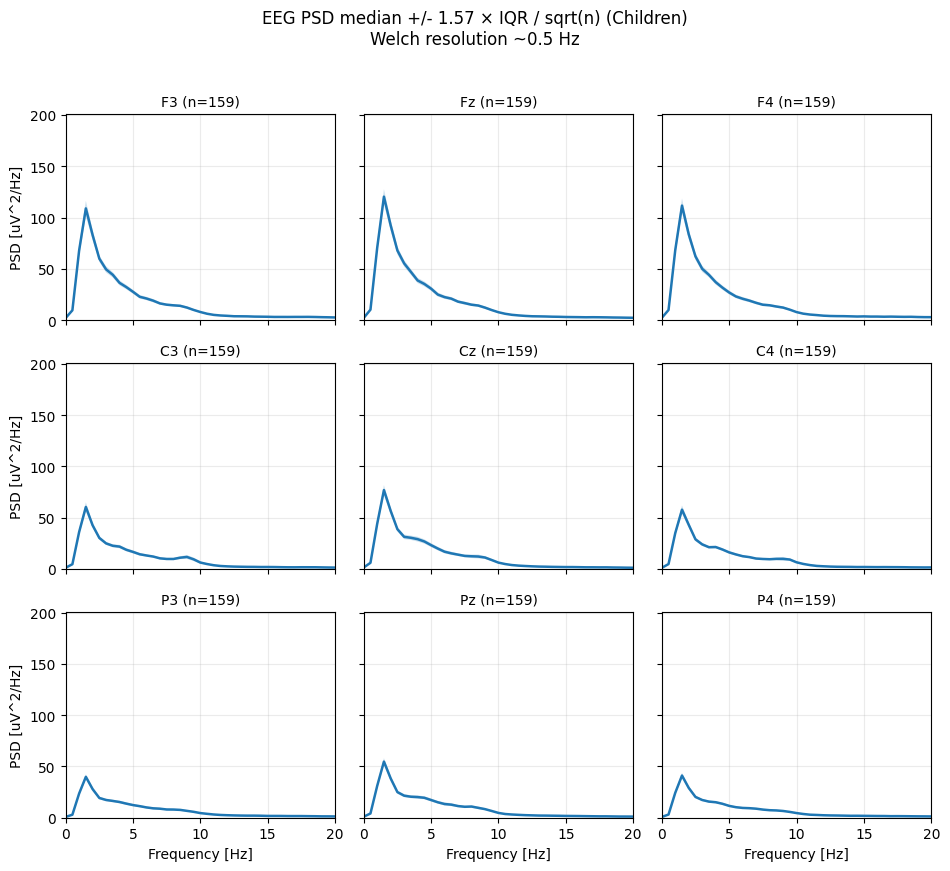

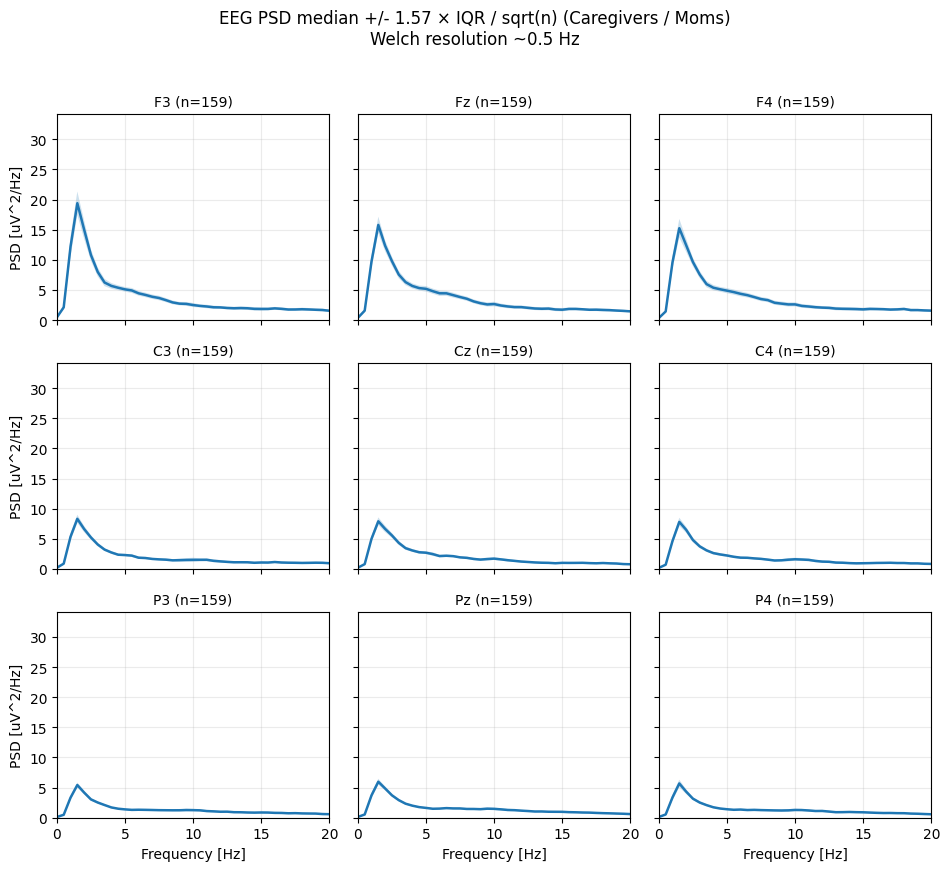

In [6]:
# PSD median +/- notch-style CI in topographic grid (analogous layout, split by role)
import numpy as np
import matplotlib.pyplot as plt

required_vars = ['psd_by_role', 'analysis_channels', 'row_channels', 'max_cols']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f'Missing variables from Cell 6: {missing}. Run Cell 6 first.')

def _stack_psd_on_common_freq_notch(traces, fmax):
    """Align spectra to a common frequency grid and return matrix (n_traces x n_freq)."""
    if not traces:
        return None, None

    ref_freqs = None
    ref_len = -1
    for freqs, pxx, event, dyad_id in traces:
        keep = np.isfinite(freqs) & np.isfinite(pxx) & (freqs <= fmax) & (freqs >= 0)
        f = freqs[keep]
        if f.size > ref_len:
            ref_freqs = f
            ref_len = f.size

    if ref_freqs is None or ref_freqs.size < 2:
        return None, None

    stacked = []
    for freqs, pxx, event, dyad_id in traces:
        keep = np.isfinite(freqs) & np.isfinite(pxx) & (freqs <= fmax) & (freqs >= 0)
        f = freqs[keep]
        y = pxx[keep]
        if f.size < 2:
            continue

        y_interp = np.full(ref_freqs.shape, np.nan, dtype=float)
        overlap = (ref_freqs >= f.min()) & (ref_freqs <= f.max())
        if np.any(overlap):
            y_interp[overlap] = np.interp(ref_freqs[overlap], f, y)
        stacked.append(y_interp)

    if not stacked:
        return None, None
    return ref_freqs, np.vstack(stacked)

def _robust_ymax_from_notch(role_key, fmax):
    maxima = []
    for ch_name in analysis_channels:
        for freqs, pxx, event, dyad_id in psd_by_role[role_key].get(ch_name, []):
            keep = np.isfinite(freqs) & np.isfinite(pxx) & (freqs <= fmax) & (freqs >= 0)
            vals = pxx[keep]
            if vals.size:
                maxima.append(np.max(vals))

    y = np.asarray(maxima, dtype=float)
    y = y[np.isfinite(y)]
    if y.size == 0:
        return 1.0
    q1 = np.percentile(y, 25)
    q3 = np.percentile(y, 75)
    iqr = q3 - q1
    ymax = q3 + 1.5 * iqr
    if not np.isfinite(ymax) or ymax <= 0:
        ymax = np.nanmax(y)
    if not np.isfinite(ymax) or ymax <= 0:
        ymax = 1.0
    return float(ymax)

def plot_role_median_notch_ci(role_key, role_label, fmax=20.0, line_lw=1.8, fill_alpha=0.22):
    ymax = _robust_ymax_from_notch(role_key, fmax)

    fig, axes = plt.subplots(3, max_cols, figsize=(3.2 * max_cols, 8.5), squeeze=False, sharex=True, sharey=True)
    fig.suptitle(
        f'EEG PSD median +/- 1.57 × IQR / sqrt(n) ({role_label})\nWelch resolution ~0.5 Hz',
        y=1.02,
    )

    rows_local = ['F', 'C', 'P']
    for r, row_name in enumerate(rows_local):
        chs = row_channels[r]
        for c in range(max_cols):
            ax = axes[r, c]
            if c >= len(chs):
                ax.axis('off')
                continue

            ch_name = chs[c]
            traces = psd_by_role[role_key].get(ch_name, [])
            if not traces:
                ax.text(0.5, 0.5, f'{ch_name}\n(no data)', ha='center', va='center', fontsize=9, transform=ax.transAxes)
                ax.set_xlim(0, fmax)
                ax.set_ylim(0, ymax)
                ax.grid(alpha=0.2)
                continue

            f_ref, mat = _stack_psd_on_common_freq_notch(traces, fmax)
            if f_ref is None or mat is None:
                ax.text(0.5, 0.5, f'{ch_name}\n(insufficient data)', ha='center', va='center', fontsize=9, transform=ax.transAxes)
                ax.set_xlim(0, fmax)
                ax.set_ylim(0, ymax)
                ax.grid(alpha=0.2)
                continue

            med = np.nanmedian(mat, axis=0)
            q1 = np.nanpercentile(mat, 25, axis=0)
            q3 = np.nanpercentile(mat, 75, axis=0)
            iqr = q3 - q1
            n_eff = np.sum(np.isfinite(mat), axis=0)

            ci_half = np.divide(
                1.57 * iqr,
                np.sqrt(np.maximum(n_eff, 1)),
                out=np.full_like(iqr, np.nan),
                where=n_eff > 0,
            )
            lower = np.clip(med - ci_half, a_min=0, a_max=None)
            upper = med + ci_half

            valid = np.isfinite(med)
            ax.plot(f_ref[valid], med[valid], lw=line_lw)
            band = np.isfinite(lower) & np.isfinite(upper)
            if np.any(band):
                ax.fill_between(f_ref[band], lower[band], upper[band], alpha=fill_alpha, linewidth=0)

            ax.set_title(f'{ch_name} (n={len(traces)})', fontsize=10)
            ax.set_xlim(0, fmax)
            ax.set_ylim(0, ymax)
            ax.grid(alpha=0.25)
            if r == 2:
                ax.set_xlabel('Frequency [Hz]')
            if c == 0:
                ax.set_ylabel('PSD [uV^2/Hz]')

    plt.tight_layout()
    plt.show()

plot_role_median_notch_ci('ch', 'Children')
plot_role_median_notch_ci('cg', 'Caregivers / Moms')



## Get the envelopes for selected band

In [7]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from copy import deepcopy
from fractions import Fraction
from scipy.signal import butter, filtfilt, hilbert, welch, resample_poly
from scipy import stats

def extract_band_envelopes(
    da,
    min_f,
    max_f,
    channels,
    downsample_fs_hz=None,
    truncate_to_event_window=False,
    filter_order=4,
    debug=False,
    psd_resolution_hz=0.05,
    welch_overlap=0.5,
):
    """Extract Hilbert envelopes for selected channels in a frequency band.

    The output preserves the input dim ordering of ``da`` after channel selection,
    so if input is (time, channel), output will also be (time, channel).

    Parameters
    ----------
    truncate_to_event_window : bool, default False
        If True, truncate the downsampled envelope to event time only:
        time in [0, event_duration], where event_duration is read from attrs
        ('event_duration' or 'event_duration_s').
    """
    if not isinstance(da, xr.DataArray):
        raise TypeError('da must be an xarray.DataArray')

    channel_dim = 'channel'
    time_dim = 'time'
    if channel_dim not in da.dims or time_dim not in da.dims:
        raise ValueError("da must have dims 'channel' and 'time'")

    if min_f <= 0 or max_f <= min_f:
        raise ValueError('Require 0 < min_f < max_f')
    if not channels:
        raise ValueError('channels list is empty')

    available_channels = da.coords[channel_dim].values
    missing = [ch for ch in channels if ch not in available_channels]
    if missing:
        raise ValueError(f'Channels not found in da: {missing}')

    fs_candidates = ['sampling_freq', 'fs', 'sfreq', 'fs_hz']
    fs = np.nan
    for key in fs_candidates:
        val = da.attrs.get(key, np.nan)
        if np.isfinite(val) and float(val) > 0:
            fs = float(val)
            break
    if not np.isfinite(fs) or fs <= 0:
        raise ValueError(
            "Sampling frequency not found in attrs. Expected one of: "
            f"{fs_candidates}"
        )

    da_sel = da.sel({channel_dim: channels})
    original_dims = tuple(da_sel.dims)

    # Process in channel x time order, then transpose back to original ordering.
    da_proc = da_sel.transpose(channel_dim, time_dim)
    x = np.asarray(da_proc.values, dtype=float)  # shape: (n_channels, n_time)

    time_vals = np.asarray(da_proc.coords[time_dim].values, dtype=float)
    if time_vals.size < 3:
        raise ValueError('Need at least 3 time points')

    nyq = fs / 2.0
    if max_f >= nyq:
        raise ValueError(f'max_f ({max_f:.3f} Hz) must be < Nyquist ({nyq:.3f} Hz)')

    wn = [min_f / nyq, max_f / nyq]
    b, a = butter(filter_order, wn, btype='bandpass')

    env = np.full_like(x, np.nan, dtype=float)
    for ci in range(x.shape[0]):
        sig = x[ci, :]
        finite = np.isfinite(sig)
        if not np.any(finite):
            continue

        sig_work = sig.copy()
        if not np.all(finite):
            idx = np.arange(sig.size)
            sig_work[~finite] = np.interp(idx[~finite], idx[finite], sig[finite])

        bp = filtfilt(b, a, sig_work, axis=-1)
        amp = np.abs(hilbert(bp, axis=-1))
        env[ci, :] = amp

    fs_out = fs
    t_out = time_vals

    if downsample_fs_hz is not None:
        downsample_fs_hz = float(downsample_fs_hz)
        if not np.isfinite(downsample_fs_hz) or downsample_fs_hz <= 0:
            raise ValueError('downsample_fs_hz must be a positive finite number')
        if downsample_fs_hz > fs:
            raise ValueError('downsample_fs_hz must be <= input sampling frequency')

        if downsample_fs_hz < fs:
            ratio = Fraction(downsample_fs_hz / fs).limit_denominator(1000)
            env = resample_poly(env, up=ratio.numerator, down=ratio.denominator, axis=1)
            fs_out = fs * ratio.numerator / ratio.denominator
            t0 = float(time_vals[0])
            t_out = t0 + np.arange(env.shape[1], dtype=float) / fs_out

    if truncate_to_event_window:
        ev_dur = da.attrs.get('event_duration', da.attrs.get('event_duration_s', np.nan))
        try:
            ev_dur = float(ev_dur)
        except Exception:
            ev_dur = np.nan
        if not np.isfinite(ev_dur) or ev_dur <= 0:
            raise ValueError(
                'truncate_to_event_window=True requires positive event duration in attrs: '
                "event_duration or event_duration_s"
            )

        keep = (t_out >= 0.0) & (t_out <= ev_dur)
        if not np.any(keep):
            raise ValueError(
                f'No samples remain after truncation to [0, {ev_dur}] s. '
                'Check time coordinates and event metadata.'
            )
        env = env[:, keep]
        t_out = t_out[keep]

    env = stats.zscore(env, axis=1, nan_policy='omit')

    env_proc = xr.DataArray(
        env,
        dims=(channel_dim, time_dim),
        coords={channel_dim: da_proc.coords[channel_dim].values, time_dim: t_out},
        attrs={
            'band_min_f_hz': float(min_f),
            'band_max_f_hz': float(max_f),
            'fs_hz': float(fs_out),
            'source_fs_hz': float(fs),
            'method': 'bandpass_butter_hilbert_amplitude_zscore',
        },
    )

    if downsample_fs_hz is not None:
        env_proc.attrs['requested_downsample_fs_hz'] = float(downsample_fs_hz)
    env_proc.attrs['truncate_to_event_window'] = int(bool(truncate_to_event_window))

    if truncate_to_event_window:
        env_proc.attrs['event_window_start_s'] = 0.0
        env_proc.attrs['event_window_end_s'] = float(t_out[-1])

    if 'child_info' in da.attrs:
        env_proc.attrs['child_info'] = deepcopy(da.attrs['child_info'])

    env_da = env_proc.transpose(*original_dims)

    if debug:
        n_ch = env_proc.sizes[channel_dim]
        fig, axes = plt.subplots(n_ch, 2, figsize=(12, max(2.5 * n_ch, 4.0)), squeeze=False)

        nperseg = int(round(fs_out / psd_resolution_hz))
        nperseg = max(8, min(nperseg, env_proc.sizes[time_dim]))
        noverlap = int(round(welch_overlap * nperseg))
        noverlap = min(max(0, noverlap), nperseg - 1)

        for i, ch in enumerate(env_proc.coords[channel_dim].values):
            y = np.asarray(env_proc.sel({channel_dim: ch}).values, dtype=float)
            t = np.asarray(env_proc.coords[time_dim].values, dtype=float)

            ax_t = axes[i, 0]
            ax_t.plot(t, y, lw=1.0)
            ax_t.set_title(f'{ch} envelope (z-scored)')
            ax_t.set_xlabel('Time [s]')
            ax_t.set_ylabel('Amplitude')
            ax_t.grid(alpha=0.3)

            ax_p = axes[i, 1]
            good = np.isfinite(y)
            if np.sum(good) >= 8:
                f, pxx = welch(y[good], fs=fs_out, nperseg=nperseg, noverlap=noverlap)
                ax_p.plot(f, pxx, lw=1.2)
            else:
                ax_p.text(0.5, 0.5, 'insufficient data', ha='center', va='center', transform=ax_p.transAxes)

            ax_p.set_title(f'{ch} envelope PSD (Welch, df~{psd_resolution_hz:.2f} Hz)')
            ax_p.set_xlabel('Frequency [Hz]')
            ax_p.set_ylabel('PSD')
            ax_p.set_xlim((0, fs_out / 2))
            ax_p.grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

    return env_da


# Example usage:
# env_alpha = extract_band_envelopes(
#     da, 8.0, 12.0, ['Fz', 'Cz', 'Pz'],
#     downsample_fs_hz=20.0, truncate_to_event_window=True, debug=True
# )
# env_alpha

In [8]:
# Smoke test: run on one available cleaned EEG file and verify output.
RUN_EXTRACT_BAND_ENVELOPES_SMOKE_TEST = False

if RUN_EXTRACT_BAND_ENVELOPES_SMOKE_TEST:
    smoke_path = '/Users/admin/Documents/Hoza/PROJEKTY/SYNCC_IN_LOCAL_HOME/DATA_film_cleaned/EEG/W_000/W_000_EEG_cg_Brave_cleaned.nc'
    with xr.open_dataarray(smoke_path) as _da_in:
        da_smoke = _da_in.load()

    print(f'data shape: {da_smoke.shape}, dims: {da_smoke.dims}, coords: {list(da_smoke.coords)}')

    preferred = analysis_channels if 'analysis_channels' in globals() else ['Fz', 'Cz', 'Pz']
    available = [str(ch) for ch in da_smoke.coords['channel'].values]
    smoke_channels = [ch for ch in preferred if ch in available]
    if len(smoke_channels) < 3:
        smoke_channels = available[: min(3, len(available))]

    band_lo = 4.0
    band_hi = 8.0
    env_candidate = extract_band_envelopes(
        da=da_smoke,
        min_f=band_lo,
        max_f=band_hi,
        channels=smoke_channels,
        downsample_fs_hz=8.0,
        filter_order=4,
        debug=True,
    )

    print(f'output shape: {env_candidate.shape}')
    print(f"output fs_hz: {env_candidate.attrs.get('fs_hz')}")
    print(f"source fs_hz: {env_candidate.attrs.get('source_fs_hz')}")

### ffDTF Envelopes: Setup and Configuration
Defines analysis parameters for envelope extraction, ffDTF frequency ranges, model-order settings, and surrogate options.

In [ ]:
# Envelope-based ffDTF batch for real and surrogate dyads (analogous to ESCan_ffdtf_batch)
from pathlib import Path
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.mtmvar import mvar_criterion, full_freq_dtf, multivariate_spectra

# ----------------------------
# Configuration
# ----------------------------
ENVELOPE_MIN_F = 8.0
ENVELOPE_MAX_F = 13.0
ENVELOPE_DOWNSAMPLE_FS_HZ = 16.0  # 8 Hz made AIC collapse to p=1 in diagnostics; 12 Hz restored p~5
ENVELOPE_TRUNCATE_TO_EVENT_WINDOW = True

MAX_MODEL_ORDER = 20
OPTIMAL_MODEL_ORDER = 5# None  # set int to force fixed order
CRIT_TYPE = 'AIC'
PLOT_CRIT = False

FREQ_MIN = 0.1
FREQ_MAX = 5.0
FREQ_STEP = 0.1
SUM_FREQ_MIN = 0.5
SUM_FREQ_MAX = 3.0

KEEP_ONLY_CROSS_PERSON = True

INCLUDE_SURROGATES = True
SURROGATE_RANDOM_SEED = 42
SURROGATE_USE_ALL = False
SURROGATE_SUBSET_SIZE = 50

# If SMOKE_TEST is True in this notebook, keep computation small.
PROCESS_ONLY_SMOKE_DYADS = bool(globals().get('SMOKE_TEST', False))
SMOKE_MAX_REAL_DYADS = 4

# Optional ffDTF debug plotting
DEBUG_PLOT_FF_DTF = False # Set True to enable ffDTF spectrum plotting for dyad-event pairs, which can be very time-consuming. 
                          # Consider also setting PROCESS_ONLY_SMOKE_DYADS=True and/or adjusting SMOKE_MAX_REAL_DYADS to limit the number of spectra plotted.
DEBUG_PLOT_FF_DTF_ONLY_CROSS = True # If True, only plot ffDTF spectra for cross-person direction (e.g. child->caregiver), 
                                    # which are typically of most interest, to reduce number of plots and runtime.
DEBUG_PLOT_FF_DTF_GRID = False
DEBUG_PLOT_FF_DTF_GRID_MAX_CH = 24
DEBUG_PLOT_FF_DTF_MAX_JOBS = SMOKE_MAX_REAL_DYADS*3  # limit total number of ffDTF spectra plotted across all dyads/events to avoid excessive runtime in smoke test.



CLEAN_RE = re.compile(r'^(W_\d+)_EEG_(ch|cg)_(.+)_cleaned$')

# Runtime counter limiting number of dyad-event debug plotting calls.
_ffdtf_plot_state = {'n_plotted': 0}

print('Cell 15 setup loaded.')

Cell 15 setup loaded.


### ffDTF Envelopes: Helper Functions
Contains channel selection, z-scoring, robust group extraction, and pair-level ffDTF computation helpers.

In [10]:
# Helper functions

def _select_common_channels(ch_child, ch_caregiver, preferred=None):
    c1 = set(map(str, ch_child))
    c2 = set(map(str, ch_caregiver))
    common = c1 & c2
    if preferred is None:
        return sorted(common)
    ordered = [ch for ch in preferred if ch in common]
    return ordered


def _debug_plot_ffdtf_grid(freqs, ff_dtf, spectra, node_names, dyad_id, event, pair_type):
    ff_abs = np.abs(ff_dtf)
    sp_abs = np.abs(spectra)
    n_nodes = ff_abs.shape[0]

    max_off = np.nanmax(ff_abs) if np.isfinite(np.nanmax(ff_abs)) else 1.0
    max_diag = np.nanmax(np.diagonal(sp_abs, axis1=0, axis2=1))
    if not np.isfinite(max_off) or max_off <= 0:
        max_off = 1.0
    if not np.isfinite(max_diag) or max_diag <= 0:
        max_diag = 1.0

    fig, axs = plt.subplots(
        n_nodes, n_nodes,
        figsize=(max(8, n_nodes * 0.8), max(8, n_nodes * 0.8)),
        gridspec_kw={'wspace': 0, 'hspace': 0},
    )

    for i in range(n_nodes):
        for j in range(n_nodes):
            ax = axs[i, j] if n_nodes > 1 else axs
            if i != j:
                y = np.real(ff_abs[i, j, :])
                ax.plot(freqs, y, lw=0.5)
                ax.fill_between(freqs, y, 0, color='skyblue', alpha=0.4)
                ax.set_ylim([0, max_off])
            else:
                y = np.real(sp_abs[i, i, :])
                ax.plot(freqs, y, lw=0.5, color=[0.7, 0.7, 0.7])
                ax.fill_between(freqs, y, 0, color=[0.7, 0.7, 0.7], alpha=0.4)
                ax.set_ylim([0, max_diag])

            ax.tick_params(
                labelleft=(j == 0),
                labelbottom=(i == n_nodes - 1),
                left=(j == 0),
                bottom=(i == n_nodes - 1),
                labelsize=4,
            )
            ax.tick_params(axis='x', labelsize=6)
            if i == n_nodes - 1:
                ax.set_xlabel(node_names[j], fontsize=8)
            if j == 0:
                ax.set_ylabel(node_names[i], fontsize=8)

    fig.suptitle(
        f'ffDTF(freq) + spectra(diag) | {dyad_id} | {event} | {pair_type}',
        fontsize=11,
    )
    plt.tight_layout()
    plt.show()


def _debug_plot_ffdtf_sum_matrix(ff_dtf_sum, node_names, use_channels, dyad_id, event, pair_type):
    plot_mat = ff_dtf_sum.copy()
    np.fill_diagonal(plot_mat, np.nan)

    if DEBUG_PLOT_FF_DTF_ONLY_CROSS:
        n_ch = len(use_channels)
        mask = np.zeros_like(plot_mat, dtype=bool)
        mask[:n_ch, n_ch:] = True
        mask[n_ch:, :n_ch] = True
        plot_mat = np.where(mask, plot_mat, np.nan)

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(plot_mat, cmap='viridis', aspect='auto')
    ax.set_title(f'ffDTF sum ({SUM_FREQ_MIN:g}-{SUM_FREQ_MAX:g} Hz) | {dyad_id} | {event} | {pair_type}')
    ticks = np.arange(len(node_names))
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_xticklabels(node_names, rotation=90, fontsize=6)
    ax.set_yticklabels(node_names, fontsize=6)
    ax.set_xlabel('Source channel')
    ax.set_ylabel('Target channel')
    fig.colorbar(im, ax=ax, label='Summed ffDTF')
    plt.tight_layout()
    plt.show()


def _extract_group_from_child_da(da_child):
    grp = np.nan

    child_info_attr = da_child.attrs.get('child_info', np.nan)
    if isinstance(child_info_attr, dict):
        grp = child_info_attr.get('group', np.nan)
    elif isinstance(child_info_attr, str) and child_info_attr.strip():
        try:
            decoded = json.loads(child_info_attr)
            if isinstance(decoded, dict):
                grp = decoded.get('group', np.nan)
        except Exception:
            pass

    if (isinstance(grp, str) and grp.strip() == '') or pd.isna(grp):
        meta = get_export_metadata(da_child)
        grp = meta.get('child_info', {}).get('group', np.nan)

    if (isinstance(grp, str) and grp.strip() == '') or pd.isna(grp):
        dyad = da_child.attrs.get('dyad_id', np.nan)
        if 'valid_dyads_df' in globals() and isinstance(dyad, str) and not valid_dyads_df.empty:
            row = valid_dyads_df.loc[valid_dyads_df['dyadID'] == dyad, 'child_group']
            if len(row) > 0:
                grp = row.iloc[0]

    if isinstance(grp, str) and grp.strip() == '':
        grp = np.nan
    return grp


def compute_pair_ffdtf_rows_from_envelopes(
    path_child: Path,
    path_caregiver: Path,
    dyad_id: str,
    event: str,
    pair_type: str,
    surrogate_pair_id=None,
    surrogate_caregiver_dyad=None,
    surrogate_child_dyad=None,
):
    da_ch = load_xarray_from_netcdf(str(path_child))
    da_cg = load_xarray_from_netcdf(str(path_caregiver))

    env_ch = extract_band_envelopes(
        da=da_ch,
        min_f=ENVELOPE_MIN_F,
        max_f=ENVELOPE_MAX_F,
        channels=[str(ch) for ch in da_ch.coords['channel'].values],
        downsample_fs_hz=ENVELOPE_DOWNSAMPLE_FS_HZ,
        truncate_to_event_window=ENVELOPE_TRUNCATE_TO_EVENT_WINDOW,
        filter_order=4,
        debug=False,
    )
    env_cg = extract_band_envelopes(
        da=da_cg,
        min_f=ENVELOPE_MIN_F,
        max_f=ENVELOPE_MAX_F,
        channels=[str(ch) for ch in da_cg.coords['channel'].values],
        downsample_fs_hz=ENVELOPE_DOWNSAMPLE_FS_HZ,
        truncate_to_event_window=ENVELOPE_TRUNCATE_TO_EVENT_WINDOW,
        filter_order=4,
        debug=False,
    )

    fs_ch = float(env_ch.attrs.get('fs_hz', np.nan))
    fs_cg = float(env_cg.attrs.get('fs_hz', np.nan))
    if not np.isfinite(fs_ch) or not np.isfinite(fs_cg):
        raise ValueError(f'Envelope fs_hz missing for {dyad_id}/{event}')
    if not np.isclose(fs_ch, fs_cg):
        raise ValueError(f'Envelope fs mismatch for {dyad_id}/{event}: child={fs_ch}, caregiver={fs_cg}')

    nyq_env = 0.5 * float(fs_ch)
    if float(FREQ_MAX) >= nyq_env:
        raise ValueError(
            f'FREQ_MAX ({FREQ_MAX}) must be < envelope Nyquist ({nyq_env:.3f} Hz). '
            f'Increase ENVELOPE_DOWNSAMPLE_FS_HZ or lower FREQ_MAX.'
        )

    preferred_channels = globals().get('analysis_channels', None)
    use_channels = _select_common_channels(
        env_ch.coords['channel'].values,
        env_cg.coords['channel'].values,
        preferred=preferred_channels,
    )
    if len(use_channels) == 0:
        raise ValueError(f'No common channels in envelopes for {dyad_id}/{event}')

    # Build channel system explicitly as (n_channels, n_time) for MVAR/ffDTF.
    sig_ch = np.asarray(
        env_ch.sel(channel=use_channels).transpose('channel', 'time').values,
        dtype=float,
    )
    sig_cg = np.asarray(
        env_cg.sel(channel=use_channels).transpose('channel', 'time').values,
        dtype=float,
    )

    if sig_ch.ndim != 2 or sig_cg.ndim != 2:
        raise ValueError(
            f'Envelope arrays must be 2D after channel/time selection. '
            f'Got child={sig_ch.shape}, caregiver={sig_cg.shape}'
        )

    n_samp = min(sig_ch.shape[1], sig_cg.shape[1])
    if n_samp < 50:
        raise ValueError(f'Too few samples after envelope extraction for {dyad_id}/{event}: {n_samp}')
    sig_ch = sig_ch[:, :n_samp]
    sig_cg = sig_cg[:, :n_samp]

    # Concatenate along channel axis: [child_channels; caregiver_channels].
    signals_joint = np.concatenate([sig_ch, sig_cg], axis=0)
    expected_shape = (2 * len(use_channels), n_samp)
    if signals_joint.shape != expected_shape:
        raise ValueError(
            f'Unexpected joint system shape for {dyad_id}/{event}: '
            f'got {signals_joint.shape}, expected {expected_shape} '
            '(n_nodes, n_time)'
        )

    node_names = [f'ch:{ch}' for ch in use_channels] + [f'cg:{ch}' for ch in use_channels]

    freqs = np.arange(FREQ_MIN, FREQ_MAX + FREQ_STEP * 0.5, FREQ_STEP)
    band_mask = (freqs >= SUM_FREQ_MIN) & (freqs <= SUM_FREQ_MAX)
    if not np.any(band_mask):
        raise ValueError('Selected summation band does not overlap ffDTF frequency grid')

    if OPTIMAL_MODEL_ORDER is None:
        _, _, p_opt = mvar_criterion(signals_joint, MAX_MODEL_ORDER, CRIT_TYPE, plot=PLOT_CRIT)
    else:
        p_opt = int(OPTIMAL_MODEL_ORDER)

    ff_dtf = full_freq_dtf(
        signals_joint,
        freqs=freqs,
        fs=float(fs_ch),
        max_model_order=MAX_MODEL_ORDER,
        optimal_model_order=p_opt,
        crit_type=CRIT_TYPE,
    )

    do_debug = bool(DEBUG_PLOT_FF_DTF or DEBUG_PLOT_FF_DTF_GRID)
    if do_debug and (_ffdtf_plot_state.get('n_plotted', 0) < int(DEBUG_PLOT_FF_DTF_MAX_JOBS)):
        if DEBUG_PLOT_FF_DTF_GRID and len(node_names) <= int(DEBUG_PLOT_FF_DTF_GRID_MAX_CH):
            spectra = multivariate_spectra(
                signals_joint,
                freqs=freqs,
                fs=float(fs_ch),
                max_model_order=MAX_MODEL_ORDER,
                optimal_model_order=p_opt,
                crit_type=CRIT_TYPE,
            )
            _debug_plot_ffdtf_grid(freqs, ff_dtf, spectra, node_names, dyad_id, event, pair_type)

    ff_dtf_sum = ff_dtf[:, :, band_mask].sum(axis=2)

    if do_debug and (_ffdtf_plot_state.get('n_plotted', 0) < int(DEBUG_PLOT_FF_DTF_MAX_JOBS)):
        if DEBUG_PLOT_FF_DTF:
            _debug_plot_ffdtf_sum_matrix(ff_dtf_sum, node_names, use_channels, dyad_id, event, pair_type)
        _ffdtf_plot_state['n_plotted'] = _ffdtf_plot_state.get('n_plotted', 0) + 1

    group = _extract_group_from_child_da(da_ch)

    if surrogate_pair_id is None:
        surrogate_pair_id = dyad_id
    if surrogate_caregiver_dyad is None:
        surrogate_caregiver_dyad = dyad_id
    if surrogate_child_dyad is None:
        surrogate_child_dyad = dyad_id

    rows = []
    n_nodes = len(node_names)
    for i in range(n_nodes):
        for j in range(n_nodes):
            if i == j:
                continue
            src = node_names[j]
            dst = node_names[i]
            edge_type = 'cross-brain' if src.split(':')[0] != dst.split(':')[0] else 'intra-brain'
            if KEEP_ONLY_CROSS_PERSON and edge_type == 'intra-brain':
                continue

            rows.append({
                'dyadID': dyad_id,
                'surrogate_pair_id': surrogate_pair_id,
                'surrogate_caregiver_dyad': surrogate_caregiver_dyad,
                'surrogate_child_dyad': surrogate_child_dyad,
                'pair_type': pair_type,
                'channel_pair': f'{src}->{dst}',
                'edge_type': edge_type,
                'ff_dtf': float(ff_dtf_sum[i, j]),
                'group': group,
                'event': event,
                'n_channels_per_person': int(len(use_channels)),
                'model_order': int(p_opt),
            })

    dbg = {
        'dyadID': dyad_id,
        'event': event,
        'pair_type': pair_type,
        'n_channels_per_person': len(use_channels),
        'n_time_samples': int(n_samp),
        'joint_shape': tuple(signals_joint.shape),
        'p_opt': int(p_opt),
        'n_rows': len(rows),
    }
    return rows, dbg

print('Cell 16 helpers loaded.')

Cell 16 helpers loaded.


### ffDTF Envelopes: Build Real and Surrogate Pairs
Builds complete child-caregiver real pairs and surrogate pair definitions from cleaned files and target events.

In [11]:
# Build real and surrogate pair lists from cleaned ICA files
all_cleaned = []
for p in sorted(Path(cleaned_signals_folder).rglob('*_cleaned.nc')):
    m = CLEAN_RE.match(p.stem)
    if m is None:
        continue
    dyad_id, role, event = m.group(1), m.group(2), m.group(3)
    if event not in TARGET_EVENTS:
        continue
    all_cleaned.append((dyad_id, event, role, p))

pair_lookup = {}
for dyad_id, event, role, p in all_cleaned:
    pair_lookup.setdefault((dyad_id, event), {})[role] = p

real_pairs_all = []
for (dyad_id, event), roles in sorted(pair_lookup.items()):
    if 'ch' in roles and 'cg' in roles:
        real_pairs_all.append((dyad_id, event, roles['ch'], roles['cg']))

if 'valid_dyads' in globals() and len(valid_dyads) > 0:
    valid_set = set(valid_dyads)
    real_pairs_all = [x for x in real_pairs_all if x[0] in valid_set]

if PROCESS_ONLY_SMOKE_DYADS:
    keep_dyads = sorted({d for d, _, _, _ in real_pairs_all})[:SMOKE_MAX_REAL_DYADS]
    keep_set = set(keep_dyads)
    real_pairs_all = [x for x in real_pairs_all if x[0] in keep_set]

if not real_pairs_all:
    raise RuntimeError('No real cleaned dyad/event pairs available for envelope ffDTF.')

print(f'Real dyad-event pairs to process: {len(real_pairs_all)}')

rng = np.random.default_rng(SURROGATE_RANDOM_SEED)
dyads_real = sorted({d for d, _, _, _ in real_pairs_all})
all_surrogate_dyads = [
    (dyad_cg, dyad_ch)
    for dyad_cg in dyads_real
    for dyad_ch in dyads_real
    if dyad_cg != dyad_ch
]

selected_surrogate_dyads = []
if INCLUDE_SURROGATES and all_surrogate_dyads:
    if SURROGATE_USE_ALL:
        selected_surrogate_dyads = list(all_surrogate_dyads)
    else:
        n_pick = min(int(SURROGATE_SUBSET_SIZE), len(all_surrogate_dyads))
        idx = rng.choice(len(all_surrogate_dyads), size=n_pick, replace=False)
        selected_surrogate_dyads = [all_surrogate_dyads[i] for i in idx]

surrogate_pairs = []
for dyad_cg, dyad_ch in selected_surrogate_dyads:
    surrogate_id = f'S_{dyad_cg}_cg__{dyad_ch}_ch'
    for event in TARGET_EVENTS:
        key_ch = (dyad_ch, event)
        key_cg = (dyad_cg, event)
        if key_ch not in pair_lookup or key_cg not in pair_lookup:
            continue
        roles_ch = pair_lookup[key_ch]
        roles_cg = pair_lookup[key_cg]
        if ('ch' in roles_ch) and ('cg' in roles_cg):
            surrogate_pairs.append((surrogate_id, event, roles_ch['ch'], roles_cg['cg'], dyad_cg, dyad_ch))

print(f'Selected surrogate caregiver-child dyads: {len(selected_surrogate_dyads)}')
print(f'Surrogate dyad-event pairs to process: {len(surrogate_pairs)}')
print('Cell 17 pair lists built.')

Real dyad-event pairs to process: 12
Selected surrogate caregiver-child dyads: 12
Surrogate dyad-event pairs to process: 36
Cell 17 pair lists built.


### ffDTF Envelopes: Run Batch and Summarize
Runs real and surrogate computations, assembles output dataframes, and prints summary diagnostics.

In [ ]:
# Compute ffDTF rows for real and surrogate pairs, then assemble outputs
all_rows = []
debug_rows = []
failed = []

# Reset plotting counter for each batch run.
_ffdtf_plot_state = {'n_plotted': 0}

for dyad_id, event, path_ch, path_cg in real_pairs_all:
    print(f'Processing REAL {dyad_id} | {event}')
    try:
        rows, dbg = compute_pair_ffdtf_rows_from_envelopes(
            path_child=path_ch,
            path_caregiver=path_cg,
            dyad_id=dyad_id,
            event=event,
            pair_type='real',
            surrogate_pair_id=dyad_id,
            surrogate_caregiver_dyad=dyad_id,
            surrogate_child_dyad=dyad_id,
        )
        all_rows.extend(rows)
        debug_rows.append(dbg)
    except Exception as exc:
        failed.append({'dyadID': dyad_id, 'event': event, 'pair_type': 'real', 'error': str(exc)})

for surrogate_id, event, path_ch, path_cg, dyad_cg, dyad_ch in surrogate_pairs:
    print(f'Processing SURROGATE {surrogate_id} | {event}')
    try:
        rows, dbg = compute_pair_ffdtf_rows_from_envelopes(
            path_child=path_ch,
            path_caregiver=path_cg,
            dyad_id=surrogate_id,
            event=event,
            pair_type='surrogate',
            surrogate_pair_id=surrogate_id,
            surrogate_caregiver_dyad=dyad_cg,
            surrogate_child_dyad=dyad_ch,
        )
        all_rows.extend(rows)
        debug_rows.append(dbg)
    except Exception as exc:
        failed.append({'dyadID': surrogate_id, 'event': event, 'pair_type': 'surrogate', 'error': str(exc)})

ffdtf_env_df = pd.DataFrame(
    all_rows,
    columns=[
        'dyadID',
        'surrogate_pair_id',
        'surrogate_caregiver_dyad',
        'surrogate_child_dyad',
        'pair_type',
        'channel_pair',
        'edge_type',
        'ff_dtf',
        'group',
        'event',
        'n_channels_per_person',
        'model_order',
    ],
)
ffdtf_env_debug_df = pd.DataFrame(debug_rows)
ffdtf_env_failed_df = pd.DataFrame(failed)

print('\nEnvelope ffDTF summary')
print(f'  Total rows: {len(ffdtf_env_df)}')
if not ffdtf_env_df.empty:
    print('  pair_type counts:')
    print(ffdtf_env_df['pair_type'].value_counts(dropna=False))
    print('  group counts:')
    print(ffdtf_env_df['group'].value_counts(dropna=False))

if not ffdtf_env_failed_df.empty:
    print(f"\nFailed pair-events: {len(ffdtf_env_failed_df)}")
    display(ffdtf_env_failed_df.head(20))

display(ffdtf_env_df.head(20))
print('Cell 18 computation complete.')